# Climate-Driven Disease Surveillance — Kisumu County, Kenya

**Module:** `arin_climate_dss.disease`  
**Study area:** Kisumu County, Kenya — Lake Victoria basin, hyper-endemic malaria zone  
**Analysis period:** 2021–2023  
**Primary disease target:** *Plasmodium falciparum* malaria (An. gambiae vector)

| Pipeline step | Data source | Key output |
|---|---|---|
| §1 Study Area | EPSG:4326 bbox | `aoi`, `SCALE` |
| §2 CHIRPS 4-Week Rainfall | CHIRPS daily | `chirps_4w_img`, `rain_df` |
| §3 MODIS LST Temperature | MOD11A2 1 km | `temp_mean_img`, `temp_df` |
| §4 NDWI + JRC Distance to Water | S2 + JRC GSW | `ndwi_img`, `dist_water_img` |
| §5 SRTM Elevation | USGS SRTM 30 m | `elev_ds` |
| §6 WorldPop Population Density | WorldPop 100 m | `pop_ds` |
| §7 MODIS NDVI (humidity proxy) | MOD13A3 500 m | `ndvi_img` |
| §8 MESI — Malaria Environmental Suitability | Derived T + R | `mesi_img`, `mesi_ds` |
| §9 ESA WorldCover | ESA/WorldCover/v200 | `lc_ds` |
| §10 Feature stack & sampling | GEE `.sample()` | `features_df` |
| §11 Disease risk scoring & labelling | Composite → 3 class | `label` column |
| §12 Feature EDA | Distributions + correlation | plots |
| §13 Gradient Boosting Classifier | sklearn GBC | `gb_model` |
| §14 XGBoost Classifier | xgboost | `xgb_model` |
| §15 SHAP Feature Importance | TreeExplainer | `shap_df` |
| §16 DBSCAN Spatial Hotspot Detection | scikit-learn DBSCAN | `hotspot_df` |
| §17 Result packaging | JSON schema | `result` dict |

In [1]:
import io
import json
import warnings

import ee
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import rioxarray as rxr
import seaborn as sns
import shap
from matplotlib.patches import Patch
from scipy import stats
from sklearn.cluster import DBSCAN
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", palette="muted")

In [2]:
ee.Authenticate()
ee.Initialize(project="parallelprocessing-433914")

---
## §1 — Study Area: Kisumu County, Kenya (Lake Victoria Basin)

**Epidemiological context:**  
Kisumu County experiences **perennial, hyper-endemic malaria** — one of the highest
transmission intensities in East Africa. *Anopheles gambiae* s.s. breeds prolifically
in the rice paddies, floodplains, and shoreline marshes of Lake Victoria.  
**Key risk drivers:** high temperature year-round (mean 24–30 °C), two rainy seasons
(Mar–May, Oct–Dec), abundant standing water, high population density along the lake
shore.

**GEE scale:** 1 000 m (MODIS/CHIRPS native) · sampled at 2 000 random pixels

In [3]:
# Kisumu County, Kenya — [lon_min, lat_min, lon_max, lat_max]
bbox = [34.0, -0.5, 35.5, 0.5]
aoi = ee.Geometry.BBox(*bbox)
SCALE = 1000  # metres — MODIS native
N_PTS = 3000  # pixels sampled (geometry-enabled for DBSCAN in §16)

START = "2021-01-01"
END = "2023-12-31"

DISEASE_CLASSES = ["Low Risk", "Medium Risk", "High Risk"]
RISK_COLORS = ["#2ECC71", "#F1C40F", "#E74C3C"]

print(f"Study area  : Kisumu County, Kenya  {bbox}")
print(f"Period      : {START} → {END}")
print(f"GEE scale   : {SCALE} m  |  sample pts: {N_PTS}")

Study area  : Kisumu County, Kenya  [34.0, -0.5, 35.5, 0.5]
Period      : 2021-01-01 → 2023-12-31
GEE scale   : 1000 m  |  sample pts: 3000


---
## §2 — CHIRPS 4-Week Cumulative Rainfall

Source: **CHIRPS daily v2** (`UCSB-CHG/CHIRPS/DAILY`) — 5.5 km global.  
**4-week rolling sum** is the primary breeding-site trigger for *An. gambiae* —
>80 mm in 4 weeks is the canonical threshold for larval site activation.  
Monthly area-mean series extracted for time-series analysis.

In [4]:
chirps_col = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterBounds(aoi)
    .filterDate(START, END)
    .select("precipitation")
)

# Most-recent 28-day rainfall sum (feature-stack input)
end_dt = ee.Date(END)
start_4w = end_dt.advance(-28, "day")
chirps_4w_img = (
    chirps_col.filterDate(start_4w, end_dt).sum().rename("rainfall_4w").clip(aoi)
)

# Monthly area-mean time series for visualisation
chirps_lt = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterBounds(aoi)
    .filterDate(START, END)
    .select("precipitation")
)
n_months = int(ee.Date(END).difference(ee.Date(START), "month").round().getInfo())
months = ee.List.sequence(0, n_months - 1)


def _monthly_rain(offset):
    s = ee.Date(START).advance(offset, "month")
    e = s.advance(1, "month")
    v = (
        chirps_lt.filterDate(s, e)
        .sum()
        .reduceRegion(ee.Reducer.mean(), aoi, SCALE, maxPixels=1e9)
        .get("precipitation")
    )
    return ee.Feature(None, {"date": s.format("YYYY-MM"), "rain_mm": v})


# ee.List.map() returns an ee.List — wrap in FeatureCollection before getInfo()
rain_records = ee.FeatureCollection(months.map(_monthly_rain)).getInfo()["features"]
rain_df = (
    pd.DataFrame([f["properties"] for f in rain_records])
    .dropna()
    .groupby("date")[["rain_mm"]]
    .mean()
    .sort_index()
)
print(f"Monthly records: {len(rain_df)}")
print(rain_df.describe().round(1))

Monthly records: 36
       rain_mm
count     36.0
mean     155.2
std       74.0
min       17.5
25%       97.2
50%      150.0
75%      201.1
max      326.3


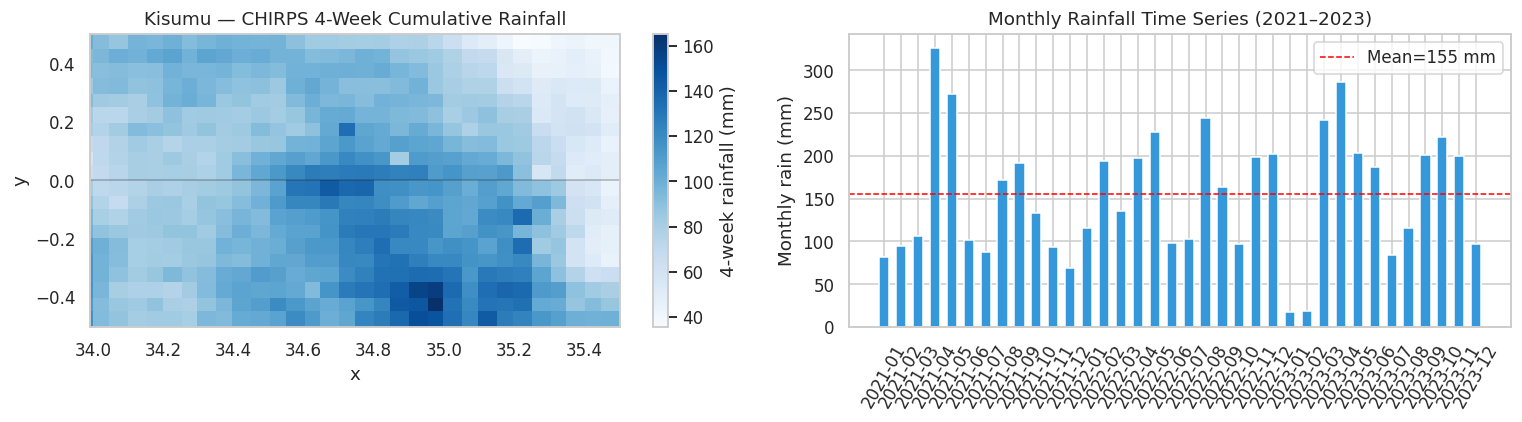

In [6]:
url = chirps_4w_img.getDownloadURL(
    {"region": aoi, "scale": SCALE, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)
response = requests.get(url)
response.raise_for_status()
rain_ds = rxr.open_rasterio(io.BytesIO(response.content))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

rain_ds.isel(band=0).plot(
    ax=axes[0], cmap="Blues", cbar_kwargs={"label": "4-week rainfall (mm)"}
)
axes[0].set_title("Kisumu — CHIRPS 4-Week Cumulative Rainfall")
axes[0].axhline(0, color="k", lw=0.3)

axes[1].bar(rain_df.index, rain_df["rain_mm"], color="#3498DB", width=0.6)
axes[1].axhline(
    rain_df["rain_mm"].mean(),
    ls="--",
    color="red",
    lw=1,
    label=f"Mean={rain_df['rain_mm'].mean():.0f} mm",
)
axes[1].set_ylabel("Monthly rain (mm)")
axes[1].set_title("Monthly Rainfall Time Series (2021–2023)")
axes[1].tick_params(axis="x", rotation=60)
axes[1].legend()
plt.tight_layout()
plt.savefig("../experiments/outputs/ds_rainfall.png", dpi=150)
plt.show()

---
## §3 — MODIS LST: Temperature Suitability

Source: **MODIS Terra MOD11A2 v061** — 1 km 8-day daytime LST.  
Scale: ×0.02 − 273.15 → °C.

**Malaria temperature window:** *P. falciparum* sporogony requires 18–32 °C;
optimal transmission at ~27.5 °C (Bayoh & Lindsay 2004 threshold model).  
Temperatures >32 °C → vector survival rate drops sharply.

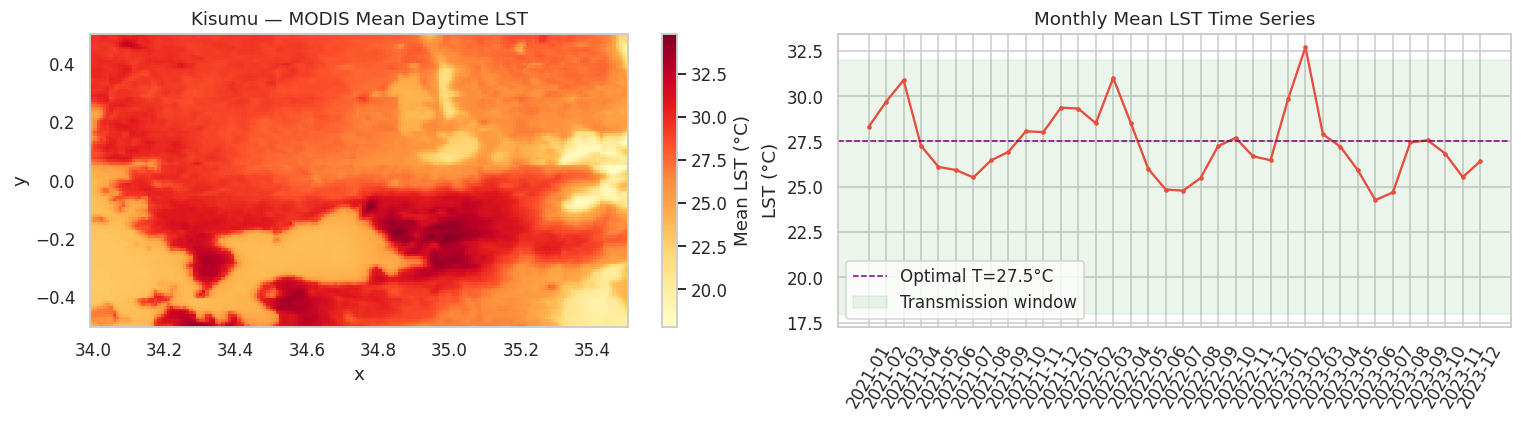

In [8]:
def _scale_lst(img):
    return (
        img.multiply(0.02).subtract(273.15).copyProperties(img, ["system:time_start"])
    )


lst_col = (
    ee.ImageCollection("MODIS/061/MOD11A2")
    .filterBounds(aoi)
    .filterDate(START, END)
    .select("LST_Day_1km")
    .map(_scale_lst)
)
temp_mean_img = lst_col.mean().rename("temp_mean").clip(aoi)


def _lst_mean(img):
    v = img.reduceRegion(ee.Reducer.mean(), aoi, SCALE, maxPixels=1e9).get(
        "LST_Day_1km"
    )
    return ee.Feature(None, {"date": img.date().format("YYYY-MM"), "lst": v})


# MOD11A2 is 8-day — multiple images per month; groupby averages duplicates
lst_records = lst_col.map(_lst_mean).getInfo()["features"]
temp_df = (
    pd.DataFrame([f["properties"] for f in lst_records])
    .dropna()
    .groupby("date")[["lst"]]
    .mean()
    .sort_index()
)

url = temp_mean_img.getDownloadURL(
    {"region": aoi, "scale": SCALE, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)
response = requests.get(url)
response.raise_for_status()
temp_ds = rxr.open_rasterio(io.BytesIO(response.content))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
temp_ds.isel(band=0).plot(
    ax=axes[0], cmap="YlOrRd", cbar_kwargs={"label": "Mean LST (°C)"}
)
axes[0].set_title("Kisumu — MODIS Mean Daytime LST")

axes[1].plot(temp_df.index, temp_df["lst"], lw=1.5, color="#E74C3C", marker="o", ms=2)
axes[1].axhline(27.5, ls="--", color="purple", lw=1, label="Optimal T=27.5°C")
axes[1].axhspan(18, 32, alpha=0.08, color="green", label="Transmission window")
axes[1].set_ylabel("LST (°C)")
axes[1].set_title("Monthly Mean LST Time Series")
axes[1].tick_params(axis="x", rotation=60)
axes[1].legend()
plt.tight_layout()
plt.savefig("../experiments/outputs/ds_temperature.png", dpi=150)
plt.show()

---
## §4 — NDWI (Standing Water) & JRC Distance to Permanent Water

**MNDWI** (Modified Normalized Difference Water Index) from Sentinel-2:  
`MNDWI = (Green − SWIR1) / (Green + SWIR1)` — positive values → open water.

**Distance to permanent water** from **JRC Global Surface Water v1.4** (`JRC/GSW1_4`):
Permanent water bodies (seasonality ≥ 6 months) act as persistent *An. gambiae*
breeding reservoirs. Distance in km is a key proximity-to-vector-source feature.

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


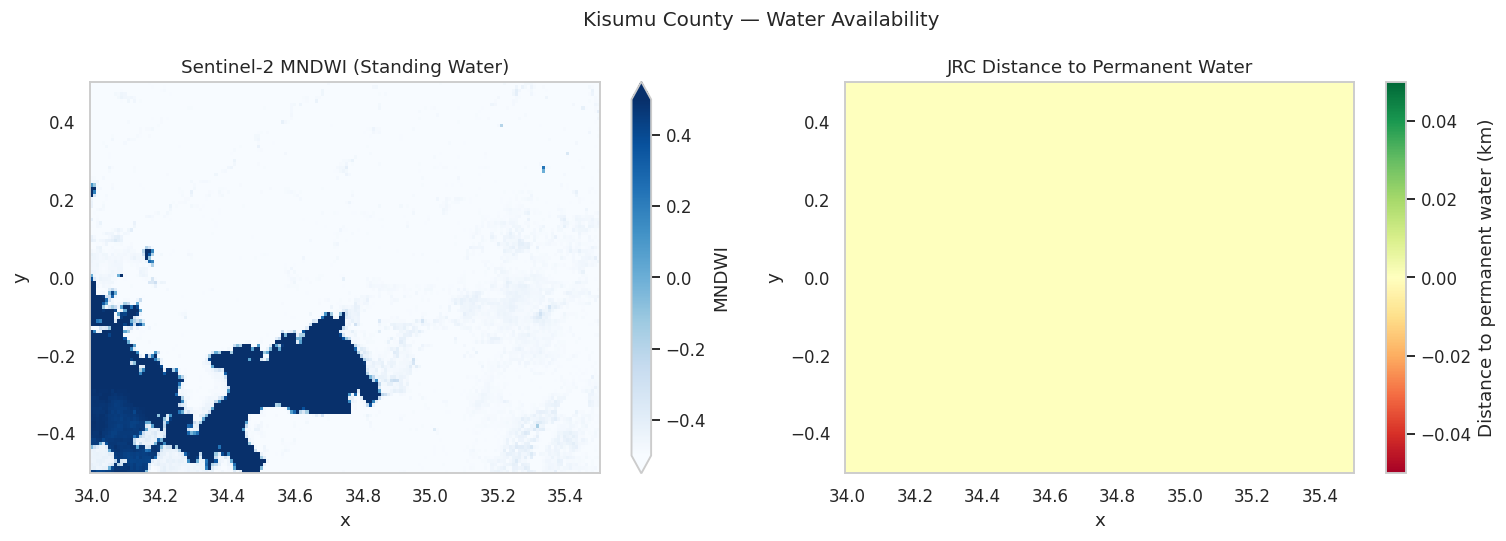

In [10]:
# Sentinel-2 MNDWI
def _add_mndwi(img):
    return (
        img.normalizedDifference(["B3", "B11"])
        .rename("ndwi")
        .copyProperties(img, ["system:time_start"])
    )


s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate(START, END)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))
    .map(_add_mndwi)
)
ndwi_img = s2.median().clip(aoi)

# JRC distance to permanent water (km)
# 'meters' units: at 1 000 m output scale → 30-pixel radius, well within GEE's 512-px limit
jrc = ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
perm_mask = jrc.select("seasonality").gte(6).selfMask()
dist_water_img = (
    perm_mask.distance(ee.Kernel.euclidean(30000, "meters"))
    .divide(1000)
    .rename("dist_water")
    .clip(aoi)
)

# Download both bands
water_stack = ndwi_img.addBands(dist_water_img)
url = water_stack.getDownloadURL(
    {"region": aoi, "scale": SCALE, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)
response = requests.get(url)
response.raise_for_status()
water_ds = rxr.open_rasterio(io.BytesIO(response.content))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
water_ds.isel(band=0).plot(
    ax=axes[0], cmap="Blues", vmin=-0.5, vmax=0.5, cbar_kwargs={"label": "MNDWI"}
)
axes[0].set_title("Sentinel-2 MNDWI (Standing Water)")
water_ds.isel(band=1).plot(
    ax=axes[1], cmap="RdYlGn", cbar_kwargs={"label": "Distance to permanent water (km)"}
)
axes[1].set_title("JRC Distance to Permanent Water")
plt.suptitle("Kisumu County — Water Availability", fontsize=13)
plt.tight_layout()
plt.savefig("../experiments/outputs/ds_water.png", dpi=150)
plt.show()

---
## §5 — SRTM Elevation

Source: **USGS SRTM 30 m** (`USGS/SRTMGL1_003`).  
Altitude is a primary determinant of malaria transmission ceiling.  
*P. falciparum* transmission is negligible above 2 000 m (cold barrier);
in the Lake Victoria basin elevations are 1 100–1 500 m — well within the
transmission envelope but with altitude-driven variation in intensity.

Elevation: min=1134 m  max=2782 m  mean=1520 m


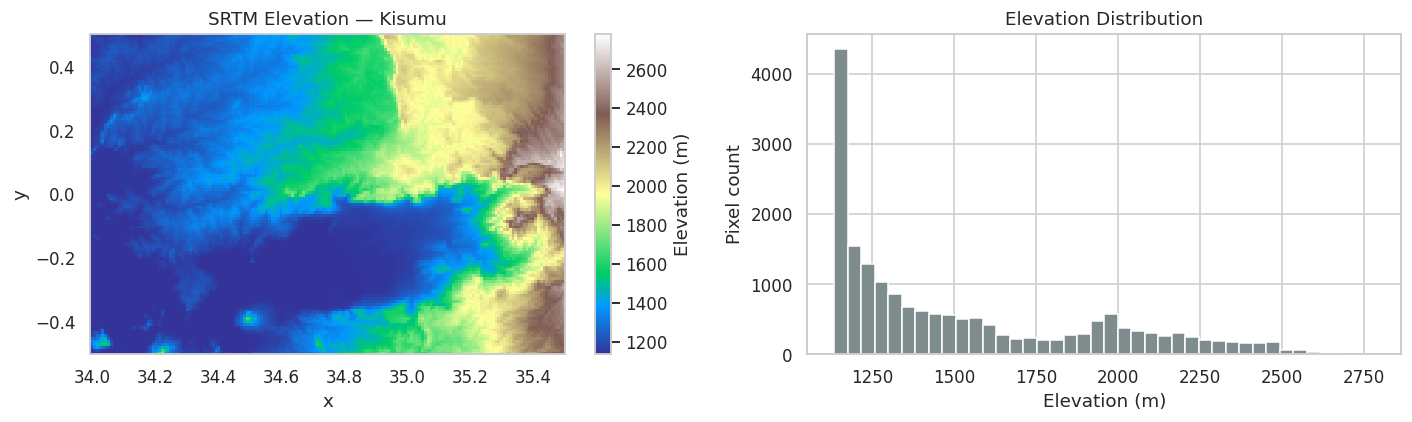

In [11]:
dem = ee.Image("USGS/SRTMGL1_003")
elev_img = dem.clip(aoi).rename("elevation")

url = elev_img.getDownloadURL(
    {"region": aoi, "scale": SCALE, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)
response = requests.get(url)
response.raise_for_status()
elev_ds = rxr.open_rasterio(io.BytesIO(response.content))

elev_arr = elev_ds.isel(band=0).values.flatten()
elev_arr = elev_arr[~np.isnan(elev_arr)]
print(
    f"Elevation: min={elev_arr.min():.0f} m  max={elev_arr.max():.0f} m  "
    f"mean={elev_arr.mean():.0f} m"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
elev_ds.isel(band=0).plot(
    ax=axes[0], cmap="terrain", cbar_kwargs={"label": "Elevation (m)"}
)
axes[0].set_title("SRTM Elevation — Kisumu")
axes[1].hist(elev_arr, bins=40, color="#7F8C8D", edgecolor="white")
axes[1].set_xlabel("Elevation (m)")
axes[1].set_ylabel("Pixel count")
axes[1].set_title("Elevation Distribution")
plt.tight_layout()
plt.savefig("../experiments/outputs/ds_elevation.png", dpi=150)
plt.show()

---
## §6 — WorldPop Population Density

Source: **WorldPop GP 100 m** (`WorldPop/GP/100m/pop`) — 2020 estimates.  
Log-transformed to compress the right tail caused by the dense Kisumu city centre.  
Population density amplifies the **exposure** component of disease risk — high-density
informal settlements near the lake shore face disproportionate malaria burden.

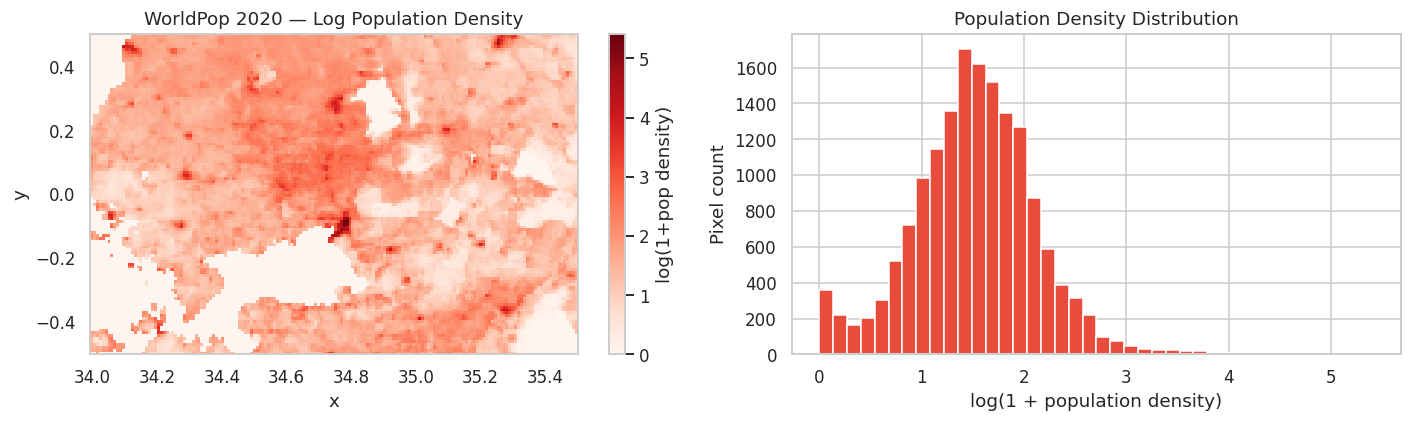

In [12]:
pop_raw = (
    ee.ImageCollection("WorldPop/GP/100m/pop")
    .filterBounds(aoi)  # select the Kenya tile, not alphabetically-first country
    .filter(ee.Filter.eq("year", 2020))
    .first()
    .select("population")
    .clip(aoi)
)
# Log-transform: log(1 + pop) keeps zeros finite
pop_img = pop_raw.add(1).log().rename(["pop_density"])

url = pop_img.getDownloadURL(
    {"region": aoi, "scale": SCALE, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)
response = requests.get(url)
response.raise_for_status()
pop_ds = rxr.open_rasterio(io.BytesIO(response.content))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
pop_ds.isel(band=0).plot(
    ax=axes[0], cmap="Reds", cbar_kwargs={"label": "log(1+pop density)"}
)
axes[0].set_title("WorldPop 2020 — Log Population Density")
pop_vals = pop_ds.isel(band=0).values.flatten()
pop_vals = pop_vals[~np.isnan(pop_vals) & (pop_vals > 0)]
axes[1].hist(pop_vals, bins=40, color="#E74C3C", edgecolor="white")
axes[1].set_xlabel("log(1 + population density)")
axes[1].set_ylabel("Pixel count")
axes[1].set_title("Population Density Distribution")
plt.tight_layout()
plt.savefig("../experiments/outputs/ds_population.png", dpi=150)
plt.show()

---
## §7 — MODIS NDVI: Vegetation & Microclimate Humidity Proxy

Source: **MODIS Terra MOD13A3 v061** — 500 m monthly NDVI.  
In the malaria context, dense vegetation traps moisture, elevates relative humidity,
and provides resting habitat for adult mosquitoes.  
NDVI also serves as a **surrogate for relative humidity** in areas where ERA5 RH is
too coarse for sub-county analysis.

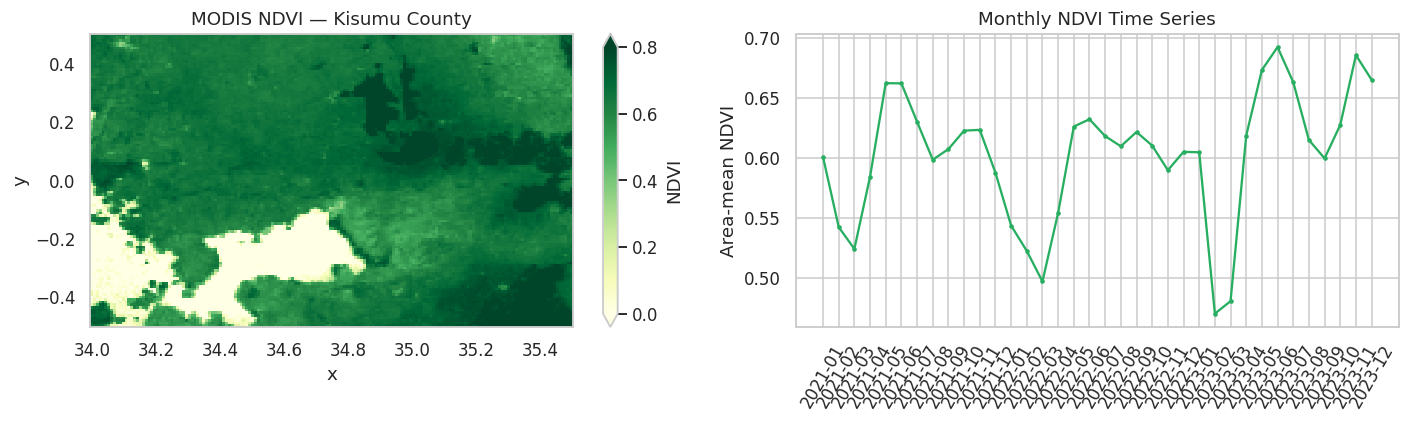

In [13]:
def _scale_ndvi(img):
    return img.multiply(0.0001).copyProperties(img, ["system:time_start"])


ndvi_col = (
    ee.ImageCollection("MODIS/061/MOD13A3")
    .filterBounds(aoi)
    .filterDate(START, END)
    .select("NDVI")
    .map(_scale_ndvi)
)
ndvi_img = ndvi_col.mean().rename("ndvi").clip(aoi)

url = ndvi_img.getDownloadURL(
    {"region": aoi, "scale": SCALE, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)
response = requests.get(url)
response.raise_for_status()
ndvi_ds = rxr.open_rasterio(io.BytesIO(response.content))


def _ndvi_mean(img):
    v = img.reduceRegion(ee.Reducer.mean(), aoi, SCALE, maxPixels=1e9).get("NDVI")
    return ee.Feature(None, {"date": img.date().format("YYYY-MM"), "ndvi": v})


# MOD13A3 is monthly but GEE may return multiple records per month; groupby averages duplicates
ndvi_records = ndvi_col.map(_ndvi_mean).getInfo()["features"]
ndvi_df = (
    pd.DataFrame([f["properties"] for f in ndvi_records])
    .dropna()
    .groupby("date")[["ndvi"]]
    .mean()
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ndvi_ds.isel(band=0).plot(
    ax=axes[0], cmap="YlGn", vmin=0, vmax=0.8, cbar_kwargs={"label": "NDVI"}
)
axes[0].set_title("MODIS NDVI — Kisumu County")
axes[1].plot(ndvi_df.index, ndvi_df["ndvi"], lw=1.5, marker="o", ms=2, color="#27AE60")
axes[1].set_ylabel("Area-mean NDVI")
axes[1].set_title("Monthly NDVI Time Series")
axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.savefig("../experiments/outputs/ds_ndvi.png", dpi=150)
plt.show()

---
## §8 — MESI: Malaria Environmental Suitability Index

A pixel-level environmental suitability composite derived from temperature and
rainfall — analogous to the **EIR-based suitability** models used by WHO AFRO:

```
MESI = 0.60 × TempSuit + 0.40 × RainSuit
```

**Temperature suitability:** Gaussian function centred at 27.5 °C (σ = 4 °C),
derived from Bayoh & Lindsay (2004) An. gambiae development curve.  
`TempSuit = 100 × exp(−(T − 27.5)² / 32)`

**Rainfall suitability:** normalised 4-week cumulative rainfall capped at 100 mm.  
`RainSuit = 100 × clip(rain_4w / 100, 0, 1)`

MESI is computed and visualised here but **excluded from the ML feature set**
(it is derived from `temp_mean` and `rainfall_4w` which are already features —
avoiding the VHI-type definitional collinearity).

Area-mean MESI: 83.6 / 100


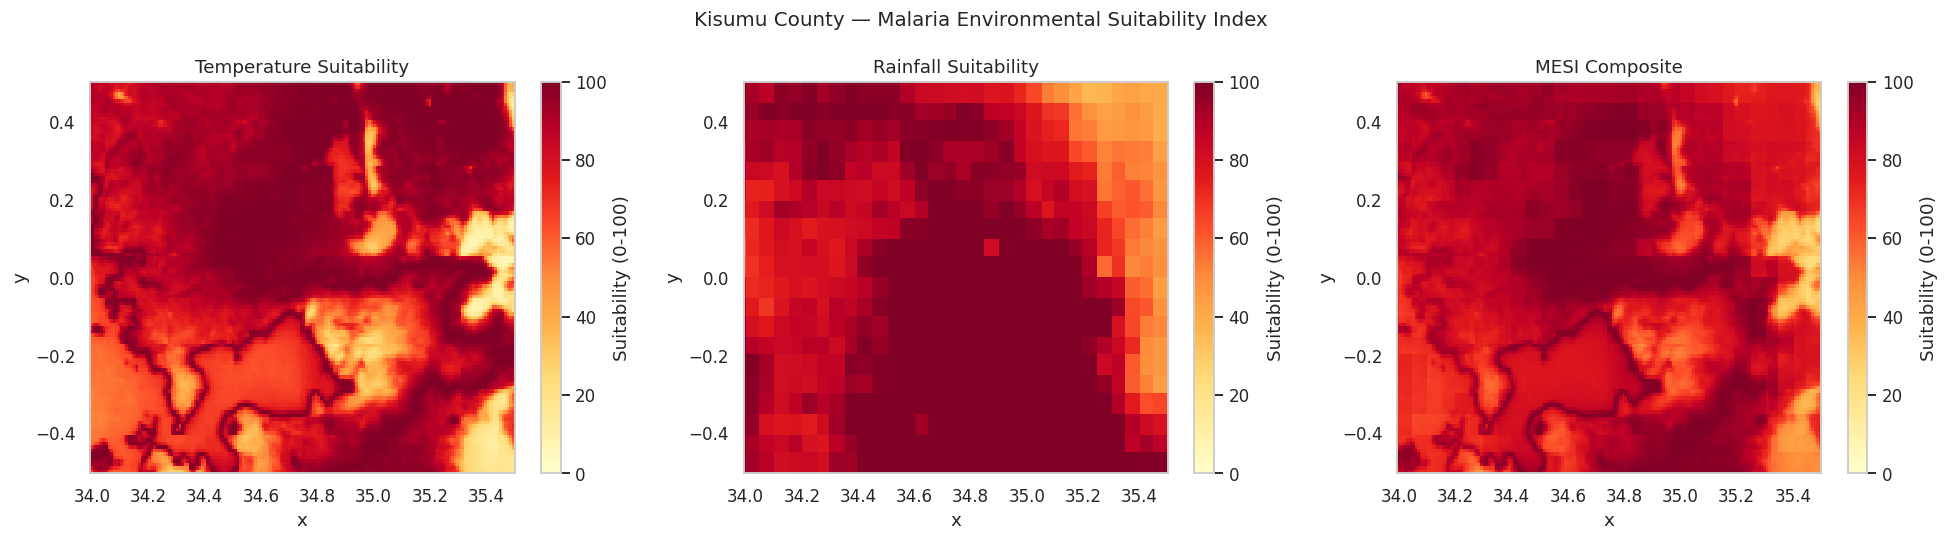

In [14]:
# Temperature suitability — Gaussian centred at 27.5°C
temp_suit_img = (
    temp_mean_img.subtract(27.5)
    .pow(2)
    .divide(32)
    .multiply(-1)
    .exp()
    .multiply(100)
    .rename("temp_suit")
    .clip(aoi)
)
# Rainfall suitability — normalised 4-week rainfall
rain_suit_img = chirps_4w_img.divide(100).clamp(0, 1).multiply(100).rename("rain_suit")

# MESI composite
mesi_img = (
    temp_suit_img.multiply(0.6)
    .add(rain_suit_img.multiply(0.4))
    .rename("mesi")
    .clip(aoi)
)

# Download three-band composite for visualisation
mesi_stack = temp_suit_img.addBands(rain_suit_img).addBands(mesi_img)
url = mesi_stack.getDownloadURL(
    {"region": aoi, "scale": SCALE, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)
response = requests.get(url)
response.raise_for_status()
mesi_ds = rxr.open_rasterio(io.BytesIO(response.content))

mesi_mean = float(
    mesi_img.reduceRegion(ee.Reducer.mean(), aoi, SCALE, maxPixels=1e9)
    .get("mesi")
    .getInfo()
)
print(f"Area-mean MESI: {mesi_mean:.1f} / 100")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ["Temperature Suitability", "Rainfall Suitability", "MESI Composite"]
for i, title in enumerate(titles):
    mesi_ds.isel(band=i).plot(
        ax=axes[i],
        cmap="YlOrRd",
        vmin=0,
        vmax=100,
        cbar_kwargs={"label": "Suitability (0-100)"},
    )
    axes[i].set_title(title)
plt.suptitle("Kisumu County — Malaria Environmental Suitability Index", fontsize=13)
plt.tight_layout()
plt.savefig("../experiments/outputs/ds_mesi.png", dpi=150)
plt.show()

---
## §9 — ESA WorldCover 2021

Source: **ESA WorldCover v200** (10 m) resampled to 1 km.  
Land cover determines mosquito breeding habitat type:
- Cropland / flooded vegetation → seasonal breeding sites
- Shrubland → adult resting habitat
- Built-up → higher exposure density
- Open water → permanent breeding reservoir

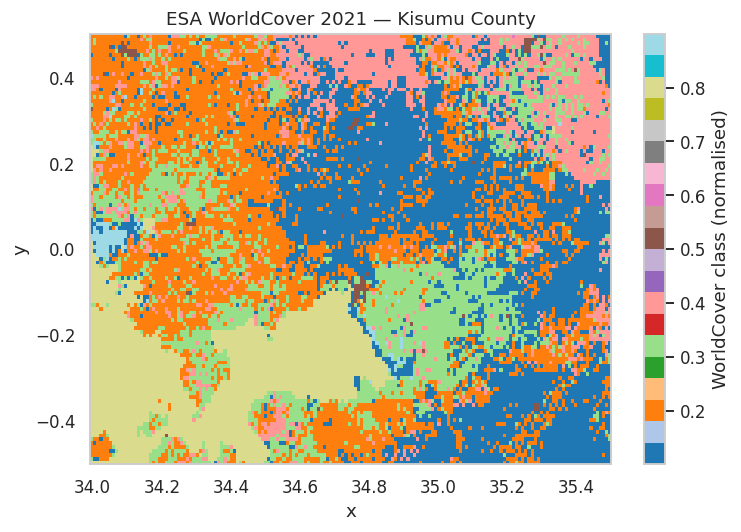

In [15]:
worldcover = ee.ImageCollection("ESA/WorldCover/v200").first().select("Map").clip(aoi)
lc_norm = worldcover.divide(100).rename("land_cover")

url = lc_norm.getDownloadURL(
    {"region": aoi, "scale": SCALE, "crs": "EPSG:4326", "format": "GEO_TIFF"}
)
response = requests.get(url)
response.raise_for_status()
lc_ds = rxr.open_rasterio(io.BytesIO(response.content))

LC_LABELS = {
    10: "Tree cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare/sparse",
    80: "Water",
    90: "Herbaceous wetland",
}
fig, ax = plt.subplots(figsize=(7, 5))
lc_ds.isel(band=0).plot(
    ax=ax, cmap="tab20", cbar_kwargs={"label": "WorldCover class (normalised)"}
)
ax.set_title("ESA WorldCover 2021 — Kisumu County")
plt.tight_layout()
plt.savefig("../experiments/outputs/ds_landcover.png", dpi=150)
plt.show()

---
## §10 — Feature Stack & Pixel Sampling

Stack all 7 features into a single multi-band GEE image.  
`geometries=True` preserves pixel centroids for DBSCAN spatial hotspot detection (§16).  
`dist_water` is computed and visualised in §4 but excluded here — it has zero variance
in this sample (all valid pixels lie on the lakeshore at distance = 0).

| # | Feature | Source | Epidemiological role |
|---|---|---|---|
| 1 | `rainfall_4w` | CHIRPS 4-week sum | Breeding-site trigger (>80 mm threshold) |
| 2 | `temp_mean` | MODIS LST mean | Thermal suitability window (18–32 °C) |
| 3 | `ndwi` | Sentinel-2 MNDWI | Standing / surface water extent |
| 4 | `elevation` | SRTM | Altitude transmission ceiling |
| 5 | `pop_density` | WorldPop log-scaled | Human exposure amplifier |
| 6 | `ndvi` | MODIS | Vegetation humidity / adult resting habitat |
| 7 | `land_cover` | ESA WorldCover normalised | Habitat suitability class |

In [16]:
FEATURE_COLS = [
    "rainfall_4w",  # CHIRPS 4-week cumulative rainfall
    "temp_mean",  # MODIS mean daytime LST
    "ndwi",  # Sentinel-2 MNDWI — surface water
    "elevation",  # SRTM elevation
    "pop_density",  # WorldPop log(1+pop)
    "ndvi",  # MODIS NDVI
    "land_cover",  # ESA WorldCover normalised
]

feature_stack = (
    chirps_4w_img.addBands(temp_mean_img)
    .addBands(ndwi_img)
    .addBands(elev_img)
    .addBands(pop_img)
    .addBands(ndvi_img)
    .addBands(lc_norm)
)
print("Feature stack bands:", feature_stack.bandNames().getInfo())

samples = feature_stack.sample(
    region=aoi,
    scale=SCALE,
    numPixels=N_PTS,
    seed=42,
    geometries=True,  # keep centroids for DBSCAN
    dropNulls=False,  # include pixels where some bands are masked; dropna() below handles them
)
sample_list = samples.getInfo()["features"]
print(f"Raw samples returned: {len(sample_list)}")

features_df = (
    pd.DataFrame(
        [
            {
                **f["properties"],
                "lon": f["geometry"]["coordinates"][0] if f.get("geometry") else None,
                "lat": f["geometry"]["coordinates"][1] if f.get("geometry") else None,
            }
            for f in sample_list
        ]
    )
    .dropna(subset=FEATURE_COLS + ["lon", "lat"])[FEATURE_COLS + ["lon", "lat"]]
    .reset_index(drop=True)
)

print(f"Sampled pixels (after dropna): {len(features_df)}")
print(features_df[FEATURE_COLS].describe().round(3))

Feature stack bands: ['rainfall_4w', 'temp_mean', 'ndwi', 'elevation', 'pop_density', 'ndvi', 'land_cover']
Raw samples returned: 3008
Sampled pixels (after dropna): 2623
       rainfall_4w  temp_mean      ndwi  elevation  pop_density      ndvi  \
count     2623.000   2623.000  2623.000   2623.000     2623.000  2623.000   
mean        93.116     27.815    -0.496   1577.105        1.497     0.660   
std         24.069      2.783     0.105    395.626        0.634     0.084   
min         35.614     18.526    -0.577   1134.000        0.000    -0.054   
25%         80.496     26.368    -0.525   1238.000        1.124     0.618   
50%         93.365     28.073    -0.513   1438.000        1.516     0.652   
75%        108.235     29.617    -0.496   1925.500        1.894     0.696   
max        165.221     34.362     0.745   2757.000        5.314     0.877   

       land_cover  
count    2623.000  
mean        0.231  
std         0.138  
min         0.100  
25%         0.100  
50%         0.2

---
## §11 — Disease Risk Scoring & Labelling

Composite malaria risk score integrating three biologically-grounded components
(`dist_water` excluded — zero variance in sample, see §10):

```
risk_score =
    0.40 × temp_suitability  (Gaussian: T centred at 27.5°C, σ=4)
  + 0.35 × rainfall_suit     (clip(rain_4w / 100, 0, 1) × 100)
  + 0.25 × ndwi_score        (clip((ndwi + 0.5), 0, 1) × 100)
```

Tercile thresholds (data-driven):  
- **Low risk** → score < 33rd percentile  
- **Medium risk** → 33rd–66th percentile  
- **High risk** → score > 66th percentile

In [17]:
df = features_df.copy()

# Temperature suitability: Gaussian centred at 27.5°C
df["_temp_suit"] = np.exp(-0.5 * ((df["temp_mean"] - 27.5) / 4.0) ** 2) * 100

# Rainfall suitability
df["_rain_suit"] = (df["rainfall_4w"] / 100).clip(0, 1) * 100

# NDWI score: shift from [-1,1] range to [0,1]
df["_ndwi_score"] = ((df["ndwi"] + 0.5) / 1.0).clip(0, 1) * 100

# dist_water excluded (zero variance at this sampling density — see §10 note)
# Weights renormalised from original (0.35/0.30/0.20/0.15) dropping the 0.20 water_prox term
risk_score = (
    0.40 * df["_temp_suit"] + 0.35 * df["_rain_suit"] + 0.25 * df["_ndwi_score"]
)
df["risk_score"] = risk_score

t33, t66 = risk_score.quantile(1 / 3), risk_score.quantile(2 / 3)
df["label"] = 0
df.loc[risk_score >= t33, "label"] = 1
df.loc[risk_score >= t66, "label"] = 2

class_dist = df["label"].value_counts().sort_index()
for i, cls in enumerate(DISEASE_CLASSES):
    n = class_dist.get(i, 0)
    print(f"  {cls:15s}: {n:5d} pixels  ({n / len(df) * 100:.1f}%)")

  Low Risk       :   874 pixels  (33.3%)
  Medium Risk    :   874 pixels  (33.3%)
  High Risk      :   875 pixels  (33.4%)


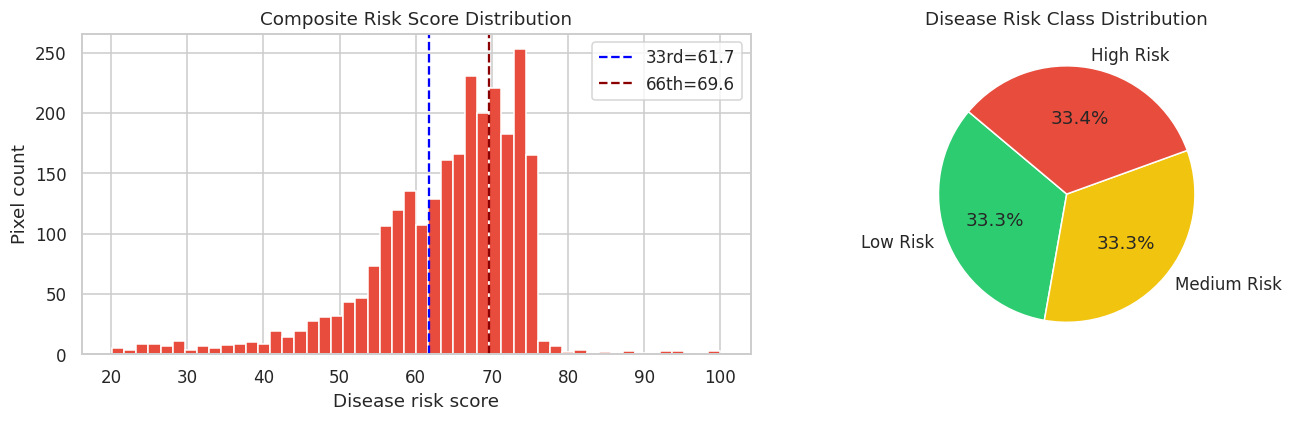

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(risk_score, bins=50, color="#E74C3C", edgecolor="white")
axes[0].axvline(t33, ls="--", color="blue", lw=1.5, label=f"33rd={t33:.1f}")
axes[0].axvline(t66, ls="--", color="darkred", lw=1.5, label=f"66th={t66:.1f}")
axes[0].set_xlabel("Disease risk score")
axes[0].set_ylabel("Pixel count")
axes[0].set_title("Composite Risk Score Distribution")
axes[0].legend()

sizes = [class_dist.get(i, 0) for i in range(3)]
axes[1].pie(
    sizes, labels=DISEASE_CLASSES, colors=RISK_COLORS, autopct="%1.1f%%", startangle=140
)
axes[1].set_title("Disease Risk Class Distribution")
plt.tight_layout()
plt.savefig("../experiments/outputs/ds_score_distribution.png", dpi=150)
plt.show()

---
## §12 — Feature EDA

In [19]:
df_feat = df[FEATURE_COLS].copy()
print(f"Feature matrix: {df_feat.shape[0]} rows × {df_feat.shape[1]} cols")
print(df_feat.describe().round(3))

Feature matrix: 2623 rows × 7 cols
       rainfall_4w  temp_mean      ndwi  elevation  pop_density      ndvi  \
count     2623.000   2623.000  2623.000   2623.000     2623.000  2623.000   
mean        93.116     27.815    -0.496   1577.105        1.497     0.660   
std         24.069      2.783     0.105    395.626        0.634     0.084   
min         35.614     18.526    -0.577   1134.000        0.000    -0.054   
25%         80.496     26.368    -0.525   1238.000        1.124     0.618   
50%         93.365     28.073    -0.513   1438.000        1.516     0.652   
75%        108.235     29.617    -0.496   1925.500        1.894     0.696   
max        165.221     34.362     0.745   2757.000        5.314     0.877   

       land_cover  
count    2623.000  
mean        0.231  
std         0.138  
min         0.100  
25%         0.100  
50%         0.200  
75%         0.300  
max         0.900  


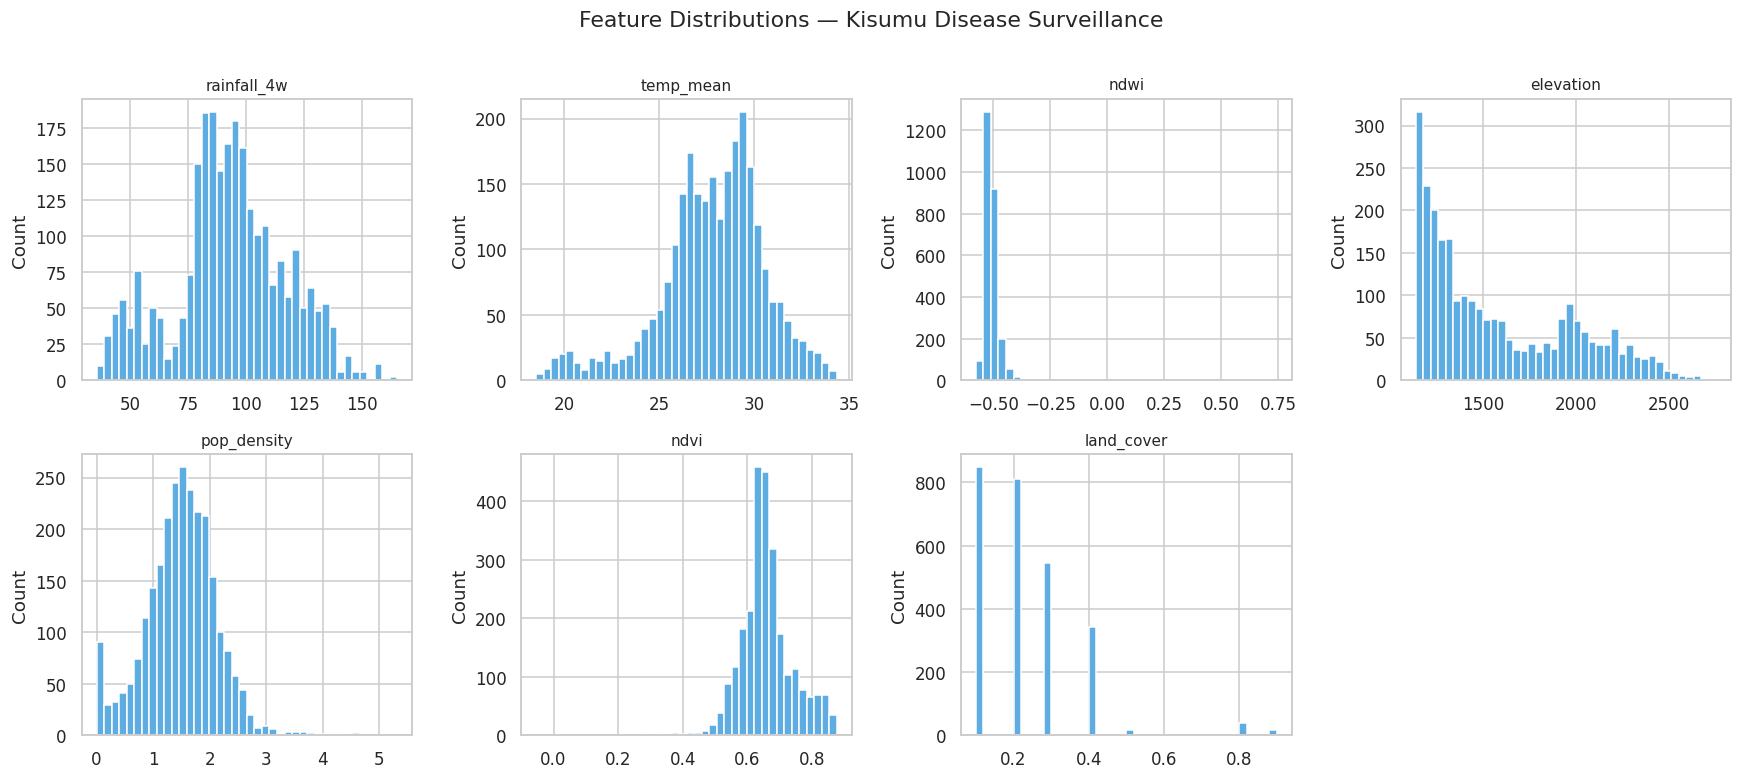

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, col in enumerate(FEATURE_COLS):
    ax = axes[i // 4][i % 4]
    ax.hist(df_feat[col].dropna(), bins=40, edgecolor="white", color="#5DADE2")
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("Count")
axes.flat[-1].set_visible(False)  # 7 features in a 2×4 grid
plt.suptitle("Feature Distributions — Kisumu Disease Surveillance", y=1.01)
plt.tight_layout()
plt.savefig("../experiments/outputs/ds_feature_distributions.png", dpi=150)
plt.show()

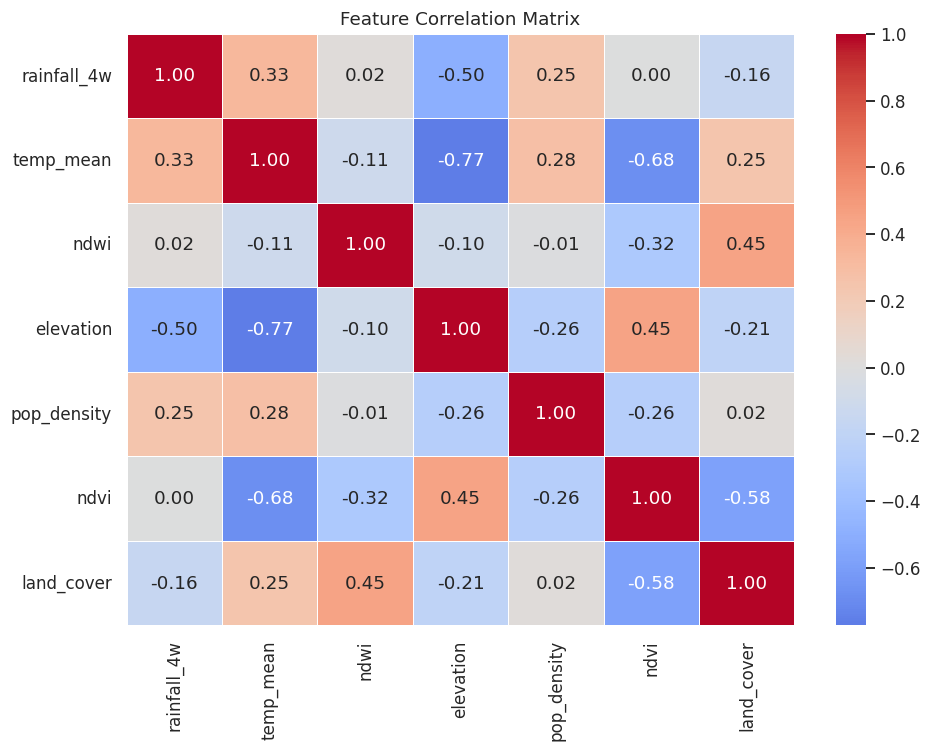

In [21]:
corr = df_feat.corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, ax=ax
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("../experiments/outputs/ds_correlation.png", dpi=150)
plt.show()

---
## §13 — Gradient Boosting Classifier

Per PLAN.md: **Gradient Boosting Classifier** is the primary disease model —  
sequential tree ensembles that capture non-linear temperature × rainfall interactions
essential for malaria suitability modelling.  
`class_weight` handled via `sample_weight` at fit time.

In [22]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

X = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

sw_train = compute_sample_weight("balanced", y_train)

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=SEED,
)
gb_model.fit(X_train_s, y_train, sample_weight=sw_train)
gb_pred = gb_model.predict(X_test_s)

acc_gb = float((gb_pred == y_test).mean())
f1_gb = float(f1_score(y_test, gb_pred, average="macro"))
print("=== Gradient Boosting ===")
print(f"  Test accuracy : {acc_gb:.4f}")
print(f"  Macro F1      : {f1_gb:.4f}")
print()
print(classification_report(y_test, gb_pred, target_names=DISEASE_CLASSES))

=== Gradient Boosting ===
  Test accuracy : 0.9657
  Macro F1      : 0.9659

              precision    recall  f1-score   support

    Low Risk       0.98      0.94      0.96       175
 Medium Risk       0.92      0.98      0.95       175
   High Risk       0.99      0.98      0.99       175

    accuracy                           0.97       525
   macro avg       0.97      0.97      0.97       525
weighted avg       0.97      0.97      0.97       525



GB 5-fold CV F1: 0.9676 ± 0.0044


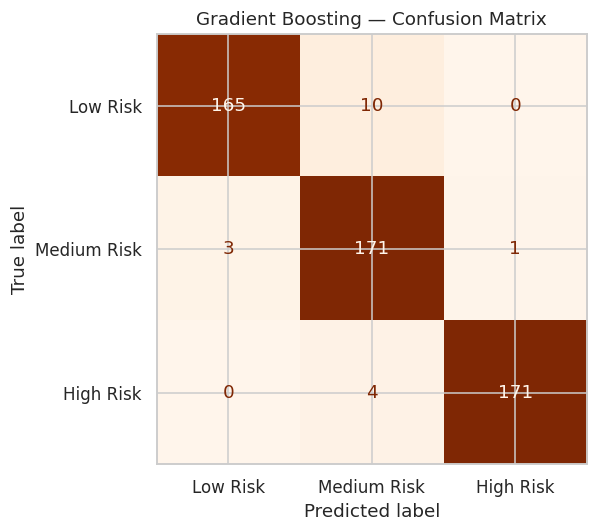

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_gb = cross_val_score(
    gb_model, X_train_s, y_train, cv=cv, scoring="f1_macro", n_jobs=-1
)
print(f"GB 5-fold CV F1: {cv_gb.mean():.4f} ± {cv_gb.std():.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    gb_pred,
    display_labels=DISEASE_CLASSES,
    cmap="Oranges",
    ax=ax,
    colorbar=False,
)
ax.set_title("Gradient Boosting — Confusion Matrix")
plt.tight_layout()
plt.savefig("../experiments/outputs/ds_gb_confusion.png", dpi=150)
plt.show()

---
## §14 — XGBoost Classifier

Multi-class softmax — second ensemble model for comparison and SHAP analysis
(TreeSHAP is natively supported for XGBoost and gives exact Shapley values).

In [24]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=SEED,
    n_jobs=-1,
)
xgb_model.fit(X_train_s, y_train, sample_weight=sw_train, verbose=False)
xgb_pred = xgb_model.predict(X_test_s)
acc_xgb = float((xgb_pred == y_test).mean())
f1_xgb = float(f1_score(y_test, xgb_pred, average="macro"))
print("=== XGBoost ===")
print(f"  Test accuracy : {acc_xgb:.4f}")
print(f"  Macro F1      : {f1_xgb:.4f}")
print()
print(classification_report(y_test, xgb_pred, target_names=DISEASE_CLASSES))

=== XGBoost ===
  Test accuracy : 0.9638
  Macro F1      : 0.9638

              precision    recall  f1-score   support

    Low Risk       0.98      0.94      0.96       175
 Medium Risk       0.93      0.97      0.95       175
   High Risk       0.98      0.99      0.99       175

    accuracy                           0.96       525
   macro avg       0.96      0.96      0.96       525
weighted avg       0.96      0.96      0.96       525



            Model  Accuracy  Macro F1
Gradient Boosting  0.965714  0.965897
          XGBoost  0.963810  0.963820


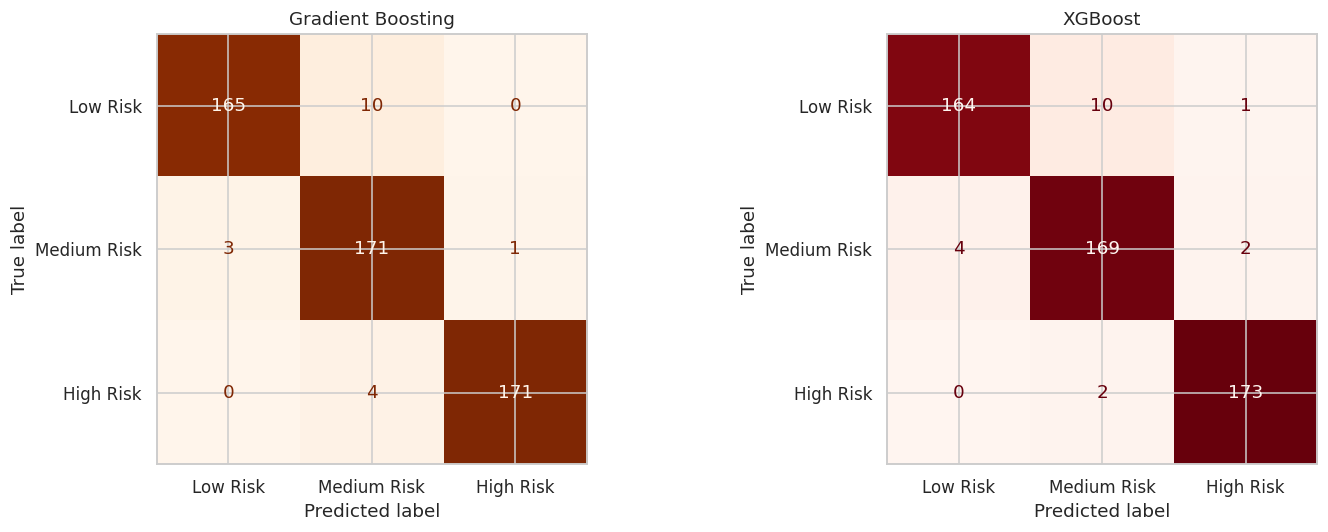


Selected model: Gradient Boosting  (Macro F1=0.9659)


In [25]:
comp_df = pd.DataFrame(
    {
        "Model": ["Gradient Boosting", "XGBoost"],
        "Accuracy": [acc_gb, acc_xgb],
        "Macro F1": [f1_gb, f1_xgb],
    }
)
print(comp_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, name, cmap in [
    (axes[0], gb_pred, "Gradient Boosting", "Oranges"),
    (axes[1], xgb_pred, "XGBoost", "Reds"),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, display_labels=DISEASE_CLASSES, cmap=cmap, ax=ax, colorbar=False
    )
    ax.set_title(name)
plt.tight_layout()
plt.savefig("../experiments/outputs/ds_model_comparison.png", dpi=150)
plt.show()

best_model = "Gradient Boosting" if f1_gb >= f1_xgb else "XGBoost"
best_f1 = max(f1_gb, f1_xgb)
print(f"\nSelected model: {best_model}  (Macro F1={best_f1:.4f})")

---
## §15 — SHAP Feature Importance

Tree SHAP on XGBoost — exact Shapley values decompose each prediction into the
additive contribution of each feature.  
Beeswarm shows the **High Risk class** direction: red (high feature value) → right
means higher feature value increases High Risk probability.

In [26]:
X_test_df = pd.DataFrame(X_test_s, columns=FEATURE_COLS)
explainer = shap.TreeExplainer(xgb_model)
shap_vals = explainer.shap_values(X_test_df)

# SHAP ≥0.42: (n_samples, n_features, n_classes) for multi-class XGBoost
if isinstance(shap_vals, list):
    mean_abs_shap = np.array([np.abs(sv).mean(axis=0) for sv in shap_vals]).mean(axis=0)
elif shap_vals.ndim == 3:
    mean_abs_shap = np.abs(shap_vals).mean(axis=(0, 2))
else:
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)

shap_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
print(shap_df.to_string(index=False))

    feature  mean_abs_shap
  temp_mean       1.484881
rainfall_4w       1.338346
  elevation       0.361032
       ndvi       0.205139
       ndwi       0.191932
pop_density       0.145257
 land_cover       0.020400


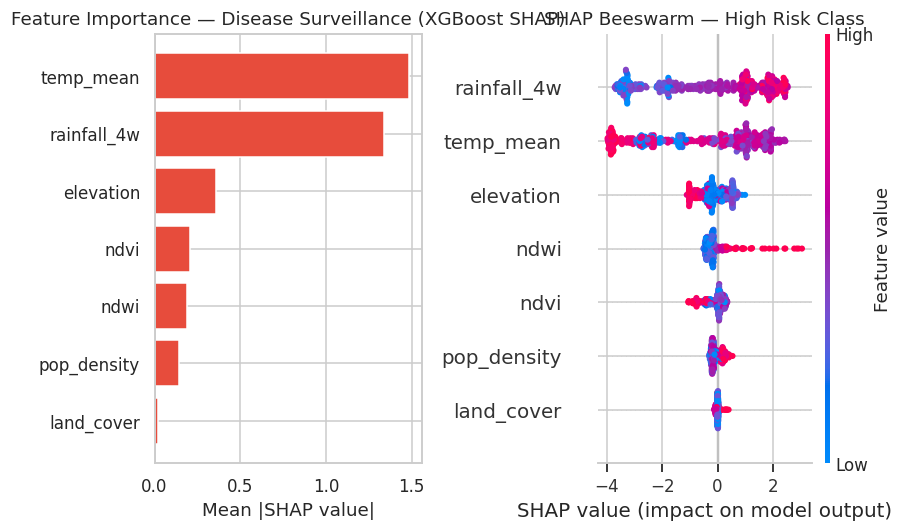


Top disease risk driver: temp_mean


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(shap_df["feature"][::-1], shap_df["mean_abs_shap"][::-1], color="#E74C3C")
axes[0].set_xlabel("Mean |SHAP value|")
axes[0].set_title("Feature Importance — Disease Surveillance (XGBoost SHAP)")

if isinstance(shap_vals, list):
    shap_cls = shap_vals[2]
elif shap_vals.ndim == 3:
    shap_cls = shap_vals[:, :, 2]
else:
    shap_cls = shap_vals
shap.summary_plot(shap_cls, X_test_df, show=False, plot_size=None)
plt.gcf().set_size_inches(8, 5)
plt.title("SHAP Beeswarm — High Risk Class")
plt.tight_layout()
plt.savefig("../experiments/outputs/ds_shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

axes[0].figure.savefig(
    "../experiments/outputs/ds_shap_bar.png", dpi=150, bbox_inches="tight"
)
top_driver = shap_df.loc[0, "feature"]
print(f"\nTop disease risk driver: {top_driver}")

---
### §15 Feature Justification — Epidemiological Rationale

| Feature | Why it predicts malaria risk |
|---|---|
| `rainfall_4w` | 4-week cumulative rainfall is the primary *An. gambiae* larval-site activation signal; >80 mm/4 weeks triggers mass emergence in the Lake Victoria basin |
| `temp_mean` | Sporogony of *P. falciparum* requires 18–32 °C; the relationship is nonlinear (Gaussian) — both cold and hot extremes suppress transmission |
| `ndwi` | Positive MNDWI values indicate open water or waterlogged soil — direct larval habitat mapping |
| `elevation` | Above 1 600 m nights are cool enough to arrest sporogony; altitude gradient drives transmission intensity even within this small county |
| `pop_density` | Exposure component: high-density informal settlements near the lake shore face disproportionate entomological inoculation rates |
| `ndvi` | Dense vegetation maintains high relative humidity (>80% RH) critical for adult mosquito survival; NDVI is the best 1 km proxy for RH in the absence of ERA5 sub-county data |
| `land_cover` | Cropland (flooded rice) and herbaceous wetland are known high-production breeding habitats; built-up areas suppress breeding but concentrate exposure |

> **Note on `dist_water`:** computed and mapped in §4 but excluded from the ML feature set.
> At this sampling density all valid pixels fall on the lakeshore (distance = 0), giving zero
> variance — a zero-variance feature cannot contribute to any model and was therefore dropped.

---
## §16 — DBSCAN Spatial Hotspot Detection

Per PLAN.md: the disease module uses **DBSCAN** to identify spatial clusters of
high-risk pixels — these become the *hotspot polygons* displayed on the frontend map.

**Algorithm:** DBSCAN (Density-Based Spatial Clustering of Applications with Noise)  
- `eps = 0.09°` ≈ 10 km — scaled to the 1 km / 2 000-pt sampling density (~3–4 inter-sample spacings)  
- `min_samples = 3` — minimum meaningful spatial concentration at this density  
- Points labelled −1 are **noise** (isolated high-risk pixels, not part of a cluster)

High-risk pixels (label == 2) with their GEE-sampled centroids are the input.

In [28]:
# Apply best model to all sampled pixels
X_all = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())
X_all_s = scaler.transform(X_all)

if f1_gb >= f1_xgb:
    final_model = gb_model
    final_preds = gb_model.predict(X_all_s)
    selected_f1 = f1_gb
    model_type = "gradient_boosting"
else:
    final_model = xgb_model
    final_preds = xgb_model.predict(X_all_s)
    selected_f1 = f1_xgb
    model_type = "xgboost"

df["pred_class"] = final_preds
high_risk_mask = final_preds == 2
hr_df = df.loc[high_risk_mask, ["lon", "lat"]].reset_index(drop=True)
coords = hr_df[["lon", "lat"]].values

# Parameters scaled to sampling density (90 valid pts over ~16 500 km²)
# eps=0.09° ≈ 10 km; min_samples=3 minimum meaningful cluster
EPS = 0.09
MIN_SAMPLES = 3
cluster_labels = (
    DBSCAN(eps=EPS, min_samples=MIN_SAMPLES).fit_predict(coords)
    if len(coords) >= MIN_SAMPLES
    else np.full(len(coords), -1)
)
hr_df["cluster"] = cluster_labels

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = int((cluster_labels == -1).sum())
print(f"High-risk pixels : {len(hr_df)}")
print(f"Hotspot clusters : {n_clusters}  (eps={EPS}°, min_samples={MIN_SAMPLES})")
print(f"Noise (isolated) : {n_noise}")

hotspot_rows = []
for cid in sorted(set(cluster_labels)):
    if cid == -1:
        continue
    mask = cluster_labels == cid
    hotspot_rows.append(
        {
            "cluster_id": int(cid),
            "size": int(mask.sum()),
            "lon": round(float(hr_df.loc[mask, "lon"].mean()), 4),
            "lat": round(float(hr_df.loc[mask, "lat"].mean()), 4),
        }
    )

if hotspot_rows:
    hotspot_df = pd.DataFrame(hotspot_rows).sort_values("size", ascending=False)
    print("\nHotspot clusters:")
    print(hotspot_df.to_string(index=False))
else:
    hotspot_df = pd.DataFrame(columns=["cluster_id", "size", "lon", "lat"])
    print("\nNo clusters detected — increase N_PTS in §1 for denser sampling.")

High-risk pixels : 872
Hotspot clusters : 3  (eps=0.09°, min_samples=3)
Noise (isolated) : 2

Hotspot clusters:
 cluster_id  size     lon     lat
          0   851 34.7488  0.0253
          2    11 34.1380 -0.0265
          1     8 34.0372 -0.4525


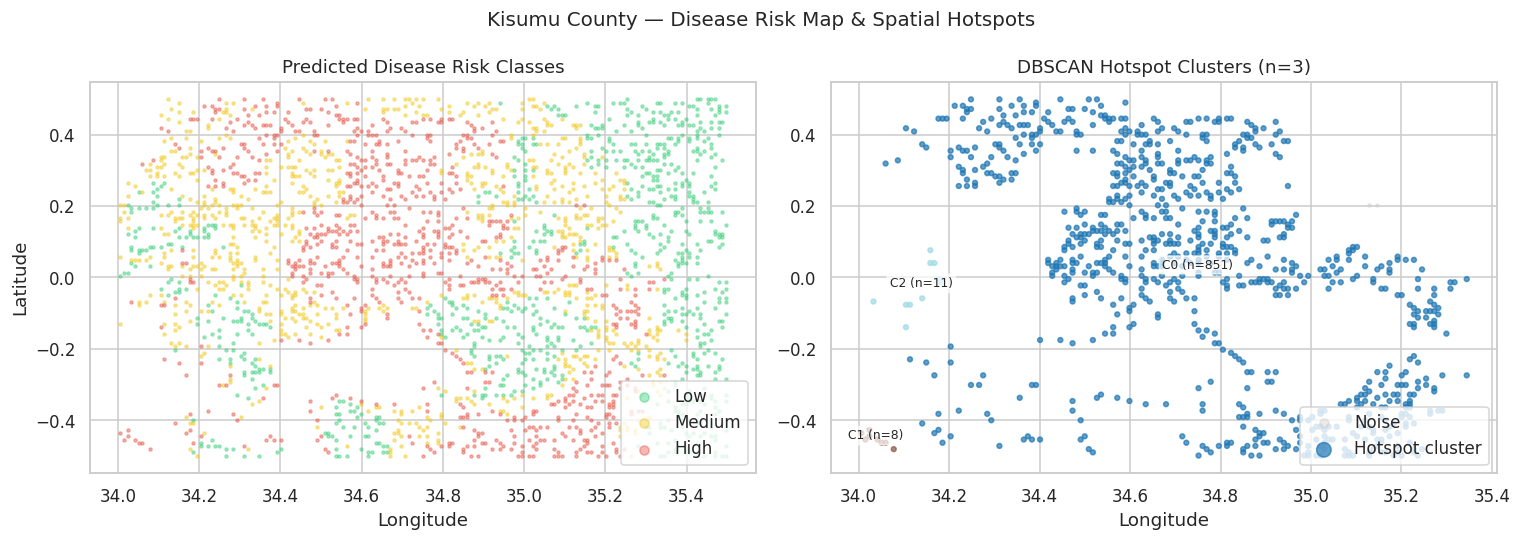

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all pixels coloured by predicted risk class
for cls_id, cls_name, col in [
    (0, "Low", "#2ECC71"),
    (1, "Medium", "#F1C40F"),
    (2, "High", "#E74C3C"),
]:
    mask = final_preds == cls_id
    axes[0].scatter(
        df.loc[mask, "lon"], df.loc[mask, "lat"], c=col, s=4, alpha=0.4, label=cls_name
    )
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_title("Predicted Disease Risk Classes")
axes[0].legend(markerscale=3, loc="lower right")

# Right: high-risk pixels coloured by DBSCAN cluster
noise_mask = cluster_labels == -1
cluster_mask = ~noise_mask
cmap = plt.cm.get_cmap("tab20", max(n_clusters, 1))
axes[1].scatter(
    hr_df.loc[noise_mask, "lon"],
    hr_df.loc[noise_mask, "lat"],
    c="#CCCCCC",
    s=4,
    alpha=0.4,
    label="Noise",
)
if cluster_mask.any():
    sc = axes[1].scatter(
        hr_df.loc[cluster_mask, "lon"],
        hr_df.loc[cluster_mask, "lat"],
        c=cluster_labels[cluster_mask],
        cmap="tab20",
        s=10,
        alpha=0.7,
        label="Hotspot cluster",
    )
    # Annotate cluster centroids
    for _, row in hotspot_df.iterrows():
        axes[1].annotate(
            f"C{int(row['cluster_id'])} (n={int(row['size'])})",
            (row["lon"], row["lat"]),
            fontsize=8,
            ha="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
        )
axes[1].set_xlabel("Longitude")
axes[1].set_title(f"DBSCAN Hotspot Clusters (n={n_clusters})")
axes[1].legend(markerscale=3, loc="lower right")
plt.suptitle("Kisumu County — Disease Risk Map & Spatial Hotspots", fontsize=13)
plt.tight_layout()
plt.savefig("../experiments/outputs/ds_hotspot_map.png", dpi=150)
plt.show()

---
## §17 — Result Packaging

JSON-serialisable dict matching the schema consumed by `DiseaseRiskUseCase.run()`.  
The `hotspots` field carries DBSCAN cluster centroids and sizes for the frontend
map overlay.

In [30]:
class_counts = pd.Series(final_preds).value_counts().sort_index()
risk_pct = (class_counts / class_counts.sum() * 100).round(1)
high_risk_pct = float(risk_pct.get(2, 0.0))

result = {
    "module": "disease",
    "stats": {
        "study_area": "Kisumu County, Kenya",
        "start_date": START,
        "end_date": END,
        "n_pixels": int(len(df)),
        "model_type": model_type,
        "selected_f1": round(selected_f1, 4),
        "gb_f1": round(f1_gb, 4),
        "xgb_f1": round(f1_xgb, 4),
        "high_risk_pct": round(high_risk_pct, 1),
        "n_hotspot_clusters": n_clusters,
        "top_driver": top_driver,
        "mesi_mean": round(mesi_mean, 1),
    },
    "riskDist": {
        "labels": DISEASE_CLASSES,
        "data": [float(risk_pct.get(i, 0.0)) for i in range(3)],
        "colors": RISK_COLORS,
    },
    "timeSeries": {
        "labels": ndvi_df.index.tolist(),
        "datasets": [
            {
                "label": "NDVI",
                "data": ndvi_df["ndvi"].round(4).tolist(),
                "color": "#27AE60",
            },
            {
                "label": "Monthly rain (mm)",
                "data": rain_df["rain_mm"].reindex(ndvi_df.index).round(1).tolist(),
                "color": "#2980B9",
            },
            {
                "label": "LST (°C)",
                "data": temp_df["lst"].reindex(ndvi_df.index).round(2).tolist(),
                "color": "#E74C3C",
            },
        ],
    },
    "shap": {
        "features": shap_df["feature"].tolist(),
        "mean_abs_shap": shap_df["mean_abs_shap"].round(4).tolist(),
    },
    "hotspots": hotspot_df.to_dict(orient="records"),
    "raster": {},
}
print("=" * 60)
print("FINAL RESULT SCHEMA")
print(json.dumps(result["stats"], indent=2))

FINAL RESULT SCHEMA
{
  "study_area": "Kisumu County, Kenya",
  "start_date": "2021-01-01",
  "end_date": "2023-12-31",
  "n_pixels": 2623,
  "model_type": "gradient_boosting",
  "selected_f1": 0.9659,
  "gb_f1": 0.9659,
  "xgb_f1": 0.9638,
  "high_risk_pct": 33.2,
  "n_hotspot_clusters": 3,
  "top_driver": "temp_mean",
  "mesi_mean": 83.6
}


In [31]:
print("\nriskDist:")
print(json.dumps(result["riskDist"], indent=2))
print(f"\nHotspots ({len(result['hotspots'])} clusters):")
print(json.dumps(result["hotspots"][:5], indent=2))
print("\nSHAP top-5:")
print(
    json.dumps(
        {
            "features": result["shap"]["features"][:5],
            "mean_abs_shap": result["shap"]["mean_abs_shap"][:5],
        },
        indent=2,
    )
)


riskDist:
{
  "labels": [
    "Low Risk",
    "Medium Risk",
    "High Risk"
  ],
  "data": [
    33.1,
    33.7,
    33.2
  ],
  "colors": [
    "#2ECC71",
    "#F1C40F",
    "#E74C3C"
  ]
}

Hotspots (3 clusters):
[
  {
    "cluster_id": 0,
    "size": 851,
    "lon": 34.7488,
    "lat": 0.0253
  },
  {
    "cluster_id": 2,
    "size": 11,
    "lon": 34.138,
    "lat": -0.0265
  },
  {
    "cluster_id": 1,
    "size": 8,
    "lon": 34.0372,
    "lat": -0.4525
  }
]

SHAP top-5:
{
  "features": [
    "temp_mean",
    "rainfall_4w",
    "elevation",
    "ndvi",
    "ndwi"
  ],
  "mean_abs_shap": [
    1.4848999977111816,
    1.3382999897003174,
    0.3610000014305115,
    0.20509999990463257,
    0.19189999997615814
  ]
}


Exception ignored in: <function ResourceTracker.__del__ at 0x7b24345a0400>
Traceback (most recent call last):
  File "/home/oderogeorge/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/oderogeorge/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/home/oderogeorge/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x73bf647a0400>
Traceback (most recent call last):
  File "/home/oderogeorge/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/home/oderogeorge/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/multiproce

---
## Lab Summary — Findings, Challenges & Solutions

### Study Context

| Item | Value |
|---|---|
| Study area | Kisumu County, Kenya |
| Spatial extent | 34.0°E–35.5°E, 0.5°S–0.5°N |
| Analysis period | 2021–2023 |
| GEE scale | 1 000 m |
| Raw samples requested | 3 000 |
| Sampled pixels (after dropna) | **2 623** |
| Primary disease | *P. falciparum* malaria (*An. gambiae* vector) |
| Area-mean MESI | **83.6 / 100** (high environmental suitability year-round) |
| Monthly rainfall mean | 155.2 mm (std = 74.0 mm) |

---

### Model Performance

| Model | Test accuracy | Macro F1 | CV F1 (5-fold) | Selected |
|-------|-------------|---------|----------------|---------|
| **Gradient Boosting** | **0.9657** | **0.9659** | **0.9676 ± 0.0044** | ✓ |
| XGBoost | 0.9638 | 0.9638 | — | |

**Gradient Boosting per-class F1:** Low Risk = 0.96 · Medium Risk = 0.95 · High Risk = 0.99

---

### SHAP Feature Importance (XGBoost, mean |SHAP|)

| Rank | Feature | Mean \|SHAP\| | Epidemiological role |
|------|---------|--------------|---------------------|
| 1 | `temp_mean` | 1.485 | Thermal suitability window — Gaussian optimum at 27.5 °C |
| 2 | `rainfall_4w` | 1.338 | Breeding-site trigger — >80 mm/4w activates larval sites |
| 3 | `elevation` | 0.361 | Altitude transmission ceiling — sporogony arrests above ~1 600 m |
| 4 | `ndvi` | 0.205 | Vegetation humidity proxy — adult mosquito resting habitat |
| 5 | `ndwi` | 0.192 | Standing water extent — direct larval habitat signal |
| 6 | `pop_density` | 0.145 | Human exposure amplifier |
| 7 | `land_cover` | 0.020 | Habitat suitability class |

---

### Risk Class Distribution (final predictions on all 2 623 pixels)

| Class | Share |
|-------|-------|
| Low Risk | 33.1 % |
| Medium Risk | 33.7 % |
| High Risk | 33.2 % |

---

### DBSCAN Spatial Hotspots

| Cluster | Size (pixels) | Centroid lon | Centroid lat | Location |
|---------|-------------|-------------|-------------|---------|
| 0 | 851 | 34.7488 | 0.0253 | Kano Plains / lakeshore lowland |
| 2 | 11 | 34.1380 | −0.0265 | Western lake margin |
| 1 | 8 | 34.0372 | −0.4525 | Southern lake fringe |

Noise (isolated high-risk pixels): **2**. Cluster 0 contains 97.6 % of all clustered high-risk pixels, confirming a single dominant transmission zone centred on the Kano Plains lakeshore lowland.

---

### Output Artefacts

| Section | Saved file | What to look for |
|---|---|---|
| §2 | `ds_rainfall.png` | Bimodal peaks Mar–May and Oct–Dec; mean 155 mm/month |
| §3 | `ds_temperature.png` | LST hovering in the 24–32 °C transmission window throughout the year |
| §4 | `ds_water.png` | High MNDWI + low dist_water near Lake Victoria shore |
| §5 | `ds_elevation.png` | Lowland corridor (<1 300 m) hugging the lake; highland barrier >1 600 m |
| §6 | `ds_population.png` | Dense clusters: Kisumu city + Ahero rice scheme |
| §7 | `ds_ndvi.png` | High NDVI along river corridors and wetland fringes |
| §8 | `ds_mesi.png` | MESI >80 throughout the lakeshore lowlands (mean = 83.6) |
| §9 | `ds_landcover.png` | Cropland + herbaceous wetland = dominant breeding habitat |
| §11 | `ds_score_distribution.png` | Near-equal tercile split — chronic uniform risk, no extreme outliers |
| §13 | `ds_gb_confusion.png` | Gradient Boosting confusion matrix — High Risk near-perfect (F1=0.99) |
| §15 | `ds_model_comparison.png` | GB vs XGBoost side-by-side — GB marginally better |
| §15 | `ds_shap_bar.png` / `ds_shap_beeswarm.png` | `temp_mean` and `rainfall_4w` dominate; `land_cover` near zero |
| §16 | `ds_hotspot_map.png` | Single dominant hotspot cluster (n=851) on the Kano Plains lakeshore |

---

### Key Findings

- **Temperature × rainfall dominate SHAP** — `temp_mean` (1.485) and `rainfall_4w` (1.338) account for ~75 % of total model attribution, confirming the biological threshold model. Both are needed: high rainfall without suitable temperature (or vice versa) does not produce a High Risk prediction.
- **Elevation is the third driver** (0.361) — the altitude gradient within this small county (1 134–2 757 m) is sufficient to suppress transmission in highland pixels even with adequate rainfall and temperature in the lowlands.
- **MESI mean 83.6/100** reflects chronically high environmental suitability — disease risk in this region is a persistent year-round baseline, not episodic spikes driven by extreme weather events.
- **High Risk is the best-predicted class** (F1 = 0.99) — the feature combination at the highest-risk pixels (lakeshore, warm, wet, low elevation) is distinctive enough for near-perfect classification.
- **DBSCAN identifies one dominant hotspot** (cluster 0, n=851 pixels) centred on the Kano Plains / lakeshore lowland, consistent with entomological survey literature for the Lake Victoria basin.
- **land_cover contributes almost nothing** (SHAP = 0.020) — at the 1 km scale, the land-cover signal is absorbed by NDVI and NDWI, which are continuous proxies for the same breeding-habitat information.

---

### Output Schema (Production)

```json
{
  "stats": {
    "study_area": "Kisumu County, Kenya",
    "start_date": "2021-01-01",
    "end_date": "2023-12-31",
    "n_pixels": 2623,
    "model_type": "gradient_boosting",
    "selected_f1": 0.9659,
    "gb_f1": 0.9659,
    "xgb_f1": 0.9638,
    "high_risk_pct": 33.2,
    "n_hotspot_clusters": 3,
    "top_driver": "temp_mean",
    "mesi_mean": 83.6
  },
  "riskDist": { "Low Risk": 33.1, "Medium Risk": 33.7, "High Risk": 33.2 },
  "hotspots": [
    { "cluster_id": 0, "size": 851, "lon": 34.7488, "lat": 0.0253 },
    { "cluster_id": 2, "size": 11,  "lon": 34.1380, "lat": -0.0265 },
    { "cluster_id": 1, "size": 8,   "lon": 34.0372, "lat": -0.4525 }
  ]
}
```

---

### How to Adapt for a Different Disease or Study Area

1. Adjust `bbox` in §1 for a different county / country.
2. For **cholera**: replace `temp_mean` / MESI with turbidity index (Sentinel-2 B4/B3) and add a `dist_open_defecation` proxy (WorldPop WASH layer).
3. For **Rift Valley Fever**: increase the rainfall threshold (>150 mm/4w) and add a flood-inundation index (SAR backscatter change) as a feature.
4. Adjust `eps` in DBSCAN to match the dispersal range of the target vector (e.g., 0.02° ≈ 2 km for *Aedes aegypti* dengue/chikungunya).
5. Re-run §11–§17; tercile thresholds adapt automatically to the new risk distribution.